# 01 - Baseline: Логістична регресія для детекції фейкових новин

**Мета**: Створити baseline модель для бінарної класифікації фейкових новин (FAKE vs TRUE)

**Підхід**:
- Логістична регресія + TF-IDF (max_features=50000, ngram_range=(1,2))
- Препроцесинг: lowercase, стоп-слова, лематизація PyMorphy3
- Split: 80/20, stratify, SEED=42

**Метрики**: Accuracy, Precision, Recall, F1, ROC-AUC

**Візуалізації**:
- Confusion Matrix
- ROC Curve  
- Топ-20 слів FAKE vs TRUE (two subplots)

## 1. Імпорт бібліотек та налаштування

In [1]:
# Стандартні бібліотеки
import os
import sys
import random
import warnings
import re
from pathlib import Path

# Data science
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, classification_report, confusion_matrix
)
import pymorphy3
import joblib
from tqdm.auto import tqdm

# Власні утиліти
# # # # sys.path.append('..')  # Not needed  # Not needed  # Not needed  # Not needed
from utils.experiment_utils import (
    save_metrics, save_confusion_matrix, save_roc_curve,
    save_top_features, print_metrics_table
)

# Налаштування
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# SEED для відтворюваності
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✓ Бібліотеки завантажено")
print(f"✓ SEED = {SEED}")

✓ Бібліотеки завантажено
✓ SEED = 42


## 2. Завантаження датасету

In [2]:
# Шлях до датасету
DATASET_PATH = r"C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\news_detector\FINAL_DATASET.csv"

# Перевірка існування
assert os.path.exists(DATASET_PATH), f"Датасет не знайдено: {DATASET_PATH}"

# Завантаження
df = pd.read_csv(DATASET_PATH)

print(f"✓ Датасет завантажено")
print(f"  Shape: {df.shape}")
print(f"  Columns: {list(df.columns)}")
print(f"\nПерші рядки:")
display(df.head())

print(f"\nРозподіл класів:")
print(df['label'].value_counts())
print(f"\nПропущені значення:")
print(df.isnull().sum())

✓ Датасет завантажено
  Shape: (21738, 2)
  Columns: ['text', 'label']

Перші рядки:


,text,label
0,Андріївка – явка з повинною окупантів: дайджес...,0
1,У біолабораторіях України проводили досліди з ...,0
2,Білл Гейтс закликав негайно прибрати з ринку у...,0
3,Королеву Єлизавету II лікують від COVID-19 «за...,0
4,Вакцини проти COVID-19 збільшили дитячу смертн...,0



Розподіл класів:
label
0    10869
1    10869
Name: count, dtype: int64

Пропущені значення:
text     0
label    0
dtype: int64


## 3. Препроцесинг тексту

In [ ]:
morph = pymorphy3.MorphAnalyzer(lang='uk')

with open('C:/Users/igrew/OneDrive/Desktop/Course Work/stopwords_ua.txt', 'r', encoding='utf-8') as f:
    STOPWORDS = set(f.read().splitlines())

def preprocess_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    text = re.sub(r'[^а-яїієґ\s]', ' ', text)
    tokens = text.split()
    lemmatized = []
    for token in tokens:
        if len(token) > 2 and token not in STOPWORDS:
            parsed = morph.parse(token)[0]
            lemma = parsed.normal_form
            lemmatized.append(lemma)
            
    return ' '.join(lemmatized)

print("✓ Функція препроцесингу створена")
print("\nПриклад препроцесингу:")
sample_text = df['text'].iloc[0]
print(f"Оригінал: {sample_text[:100]}...")
print(f"Після: {preprocess_text(sample_text)[:100]}...")

✓ Функція препроцесингу створена

Приклад препроцесингу:
Оригінал: Андріївка – явка з повинною окупантів: дайджест пропаганди РФ за 15 серпня...
Після: андріївка явка повинний окупант дайджест пропаганда серпень...


In [4]:
# Застосування препроцесингу до всього датасету
print("Препроцесинг текстів...")
tqdm.pandas(desc="Processing")
df['text_processed'] = df['text'].progress_apply(preprocess_text)

# Видалення порожніх текстів
df = df[df['text_processed'].str.len() > 0].reset_index(drop=True)

print(f"\n✓ Препроцесинг завершено")
print(f"  Фінальний розмір: {df.shape}")

Препроцесинг текстів...


Processing:   0%|          | 0/21738 [00:00<?, ?it/s]


✓ Препроцесинг завершено
  Фінальний розмір: (21728, 3)


## 4. Розділення на train/test (80/20)

In [5]:
# Підготовка даних
X = df['text_processed'].values
y = df['label'].values

# Розділення з stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"✓ Дані розділено:")
print(f"  Train: {len(X_train)} зразків")
print(f"  Test:  {len(X_test)} зразків")
print(f"\n  Train distribution: {np.bincount(y_train)}")
print(f"  Test distribution:  {np.bincount(y_test)}")

✓ Дані розділено:
  Train: 17382 зразків
  Test:  4346 зразків

  Train distribution: [8692 8690]
  Test distribution:  [2173 2173]


## 5. TF-IDF векторизація

In [6]:
vectorizer = TfidfVectorizer(
    max_features=30000,  
    ngram_range=(1, 2), 
    min_df=2, 
    max_df=0.9, 
    sublinear_tf=True,
    use_idf=True,
    smooth_idf=True 
)

# Fit на train, transform train і test
print("Векторизація текстів...")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\n✓ TF-IDF векторизація завершена")
print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape:  {X_test_tfidf.shape}")

Векторизація текстів...

✓ TF-IDF векторизація завершена
  Vocabulary size: 30000
  Train shape: (17382, 30000)
  Test shape:  (4346, 30000)


## 6. Навчання Logistic Regression

In [7]:
# Створення та навчання моделі
print("Навчання Logistic Regression...")

model = LogisticRegression(
    C=2.0, 
    penalty='l2', 
    solver='saga', 
    class_weight='balanced', 
    random_state=42,
    max_iter=2000,  
    tol=1e-4,  
    n_jobs=-1,
    verbose=1
)

model.fit(X_train_tfidf, y_train)

print("\n✓ Навчання завершено")

Навчання Logistic Regression...
convergence after 22 epochs took 1 seconds

✓ Навчання завершено


## 7. Оцінка моделі

In [8]:
# Передбачення
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

# Обчислення метрик
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba)
}

# Вивід метрик
print_metrics_table(metrics, "Logistic Regression Baseline")

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['FAKE', 'TRUE']))


  Logistic Regression Baseline - Metrics Summary
+-----------+---------+
| Metric    |   Value |
+===========+=========+
| accuracy  |  0.8408 |
+-----------+---------+
| precision |  0.8541 |
+-----------+---------+
| recall    |  0.8219 |
+-----------+---------+
| f1        |  0.8377 |
+-----------+---------+
| roc_auc   |  0.9216 |
+-----------+---------+


Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE       0.83      0.86      0.84      2173
        TRUE       0.85      0.82      0.84      2173

    accuracy                           0.84      4346
   macro avg       0.84      0.84      0.84      4346
weighted avg       0.84      0.84      0.84      4346



## 8. Візуалізація результатів

### 8.1 Confusion Matrix

✓ Confusion matrix збережено: plots/01_baseline_confusion_matrix.png


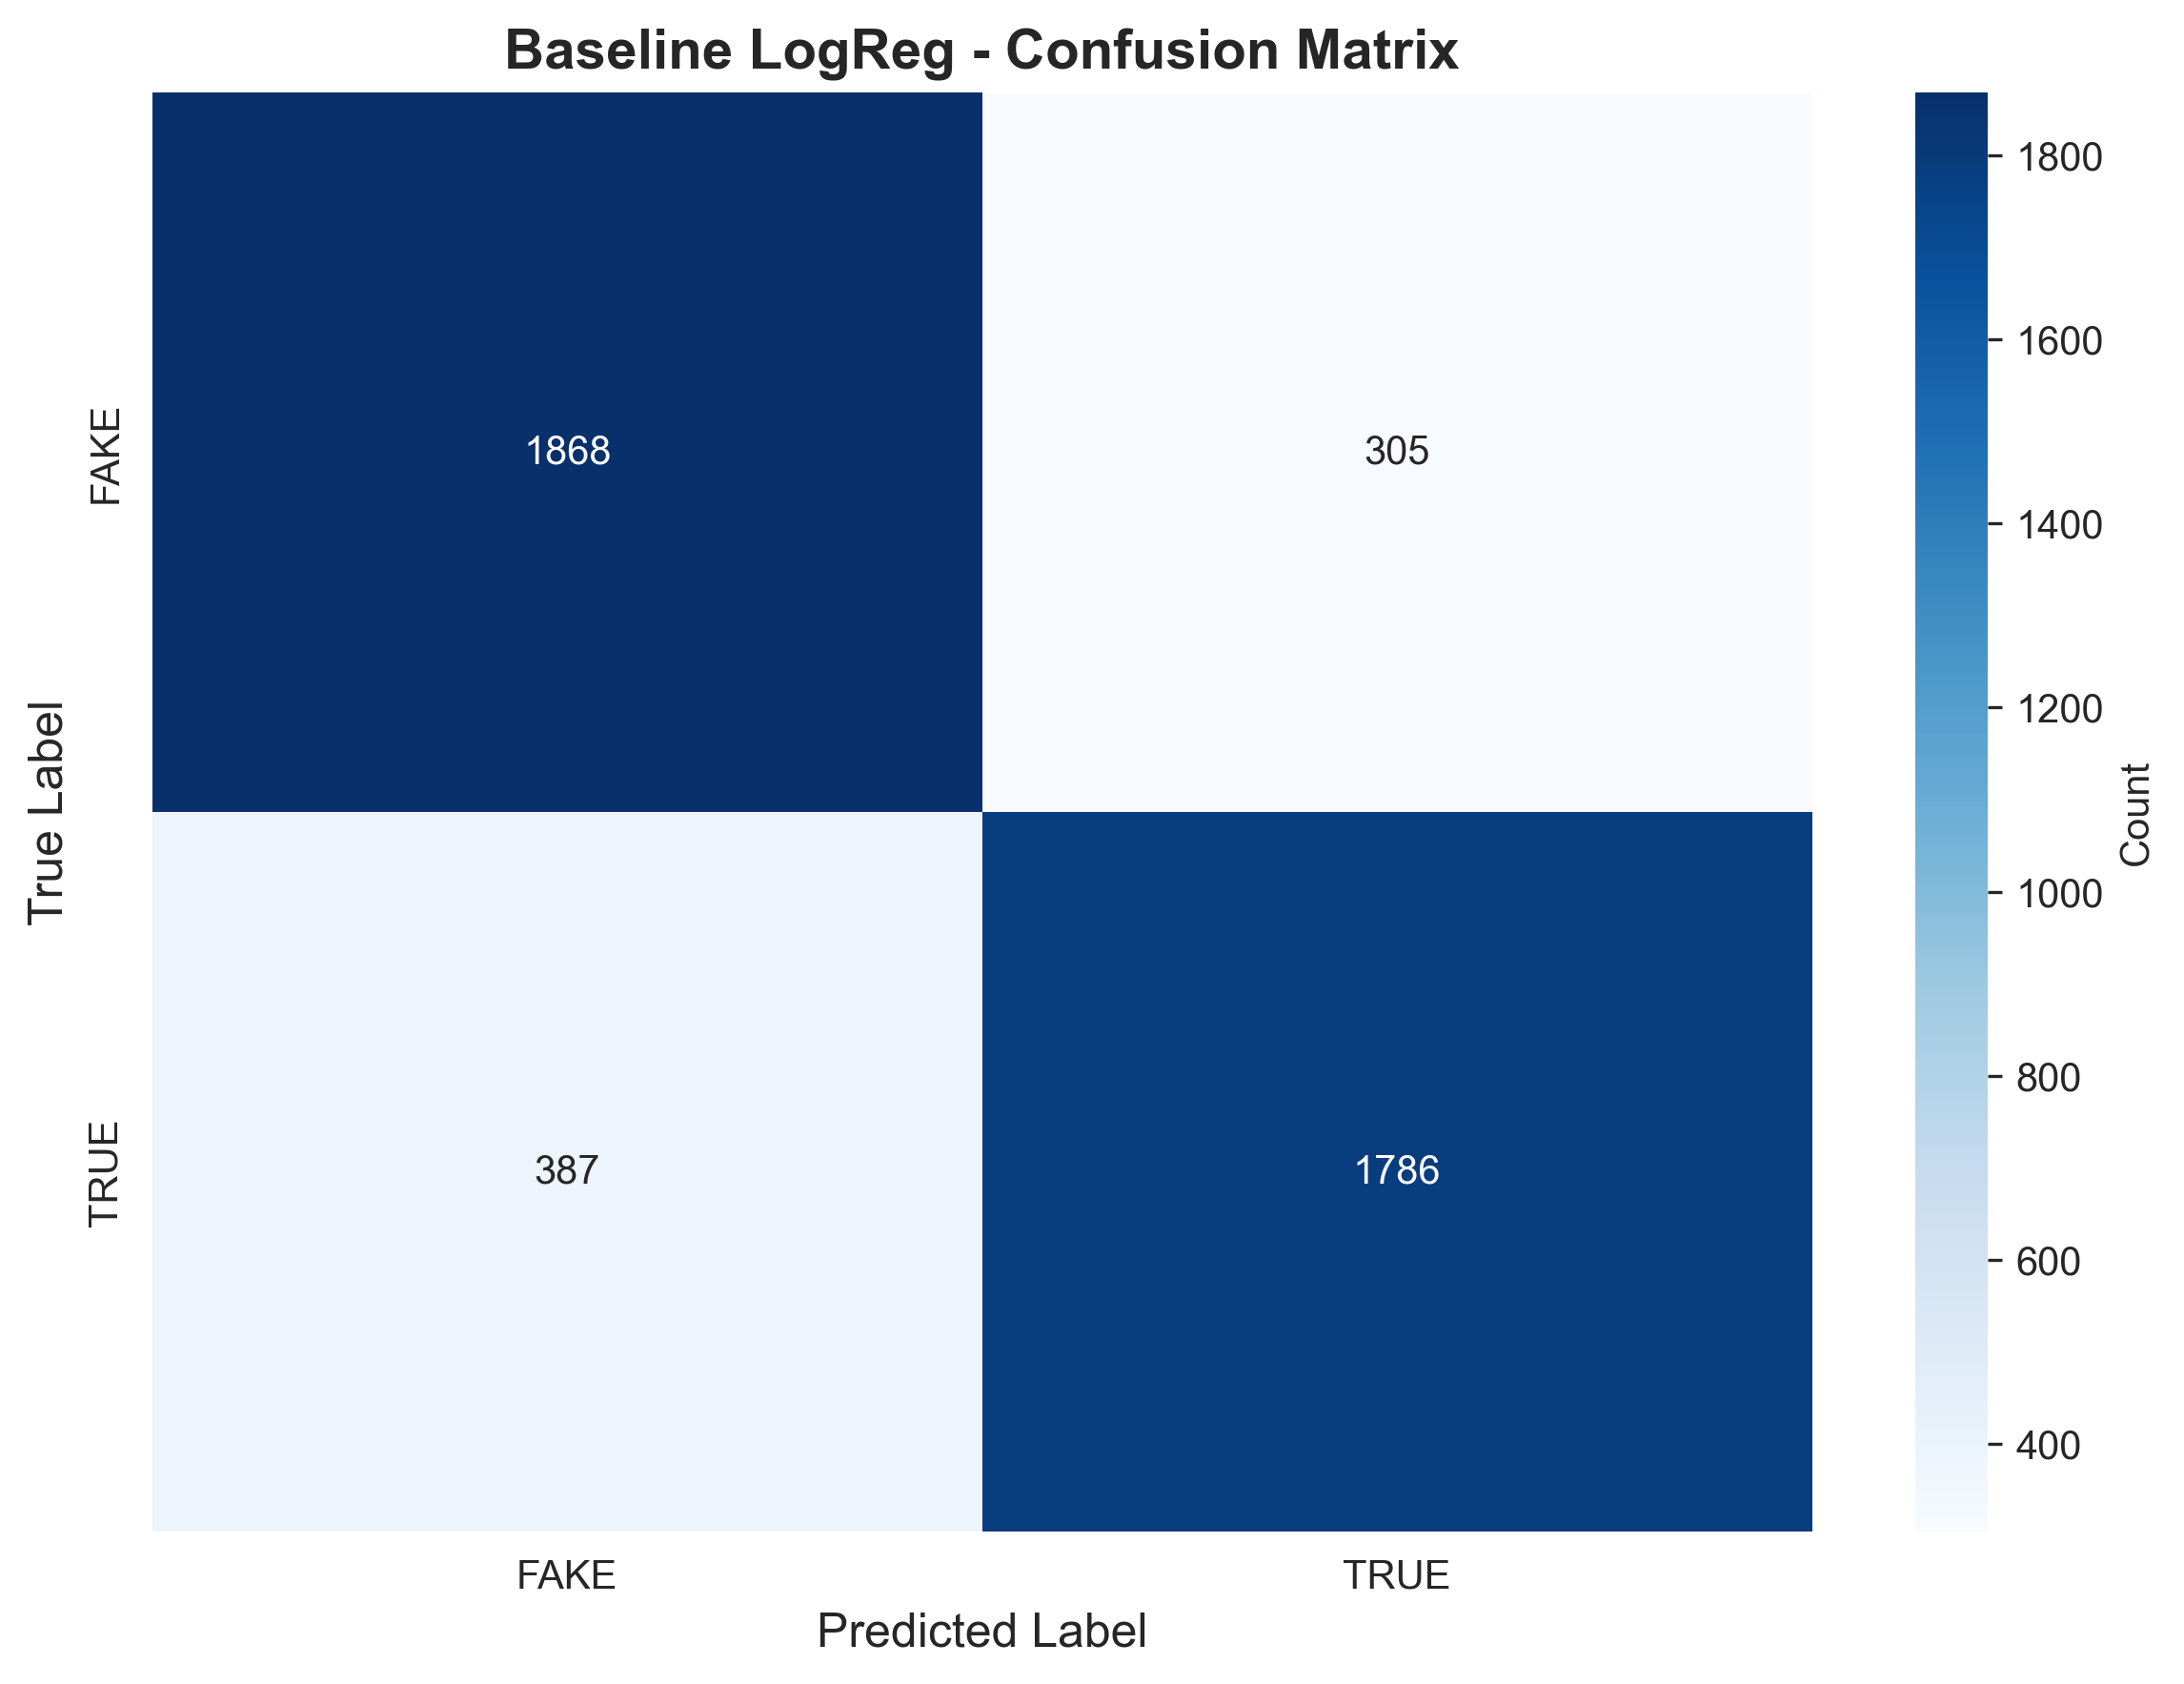

In [9]:
# Створення та збереження confusion matrix
save_confusion_matrix(
    y_test, y_pred,
    labels=['FAKE', 'TRUE'],
    path='plots/01_baseline_confusion_matrix.png',
    title='Baseline LogReg - Confusion Matrix'
)

# Відображення inline
from IPython.display import Image, display
display(Image('plots/01_baseline_confusion_matrix.png'))

### 8.2 ROC Curve

✓ ROC крива збережена: plots/01_baseline_roc_curve.png


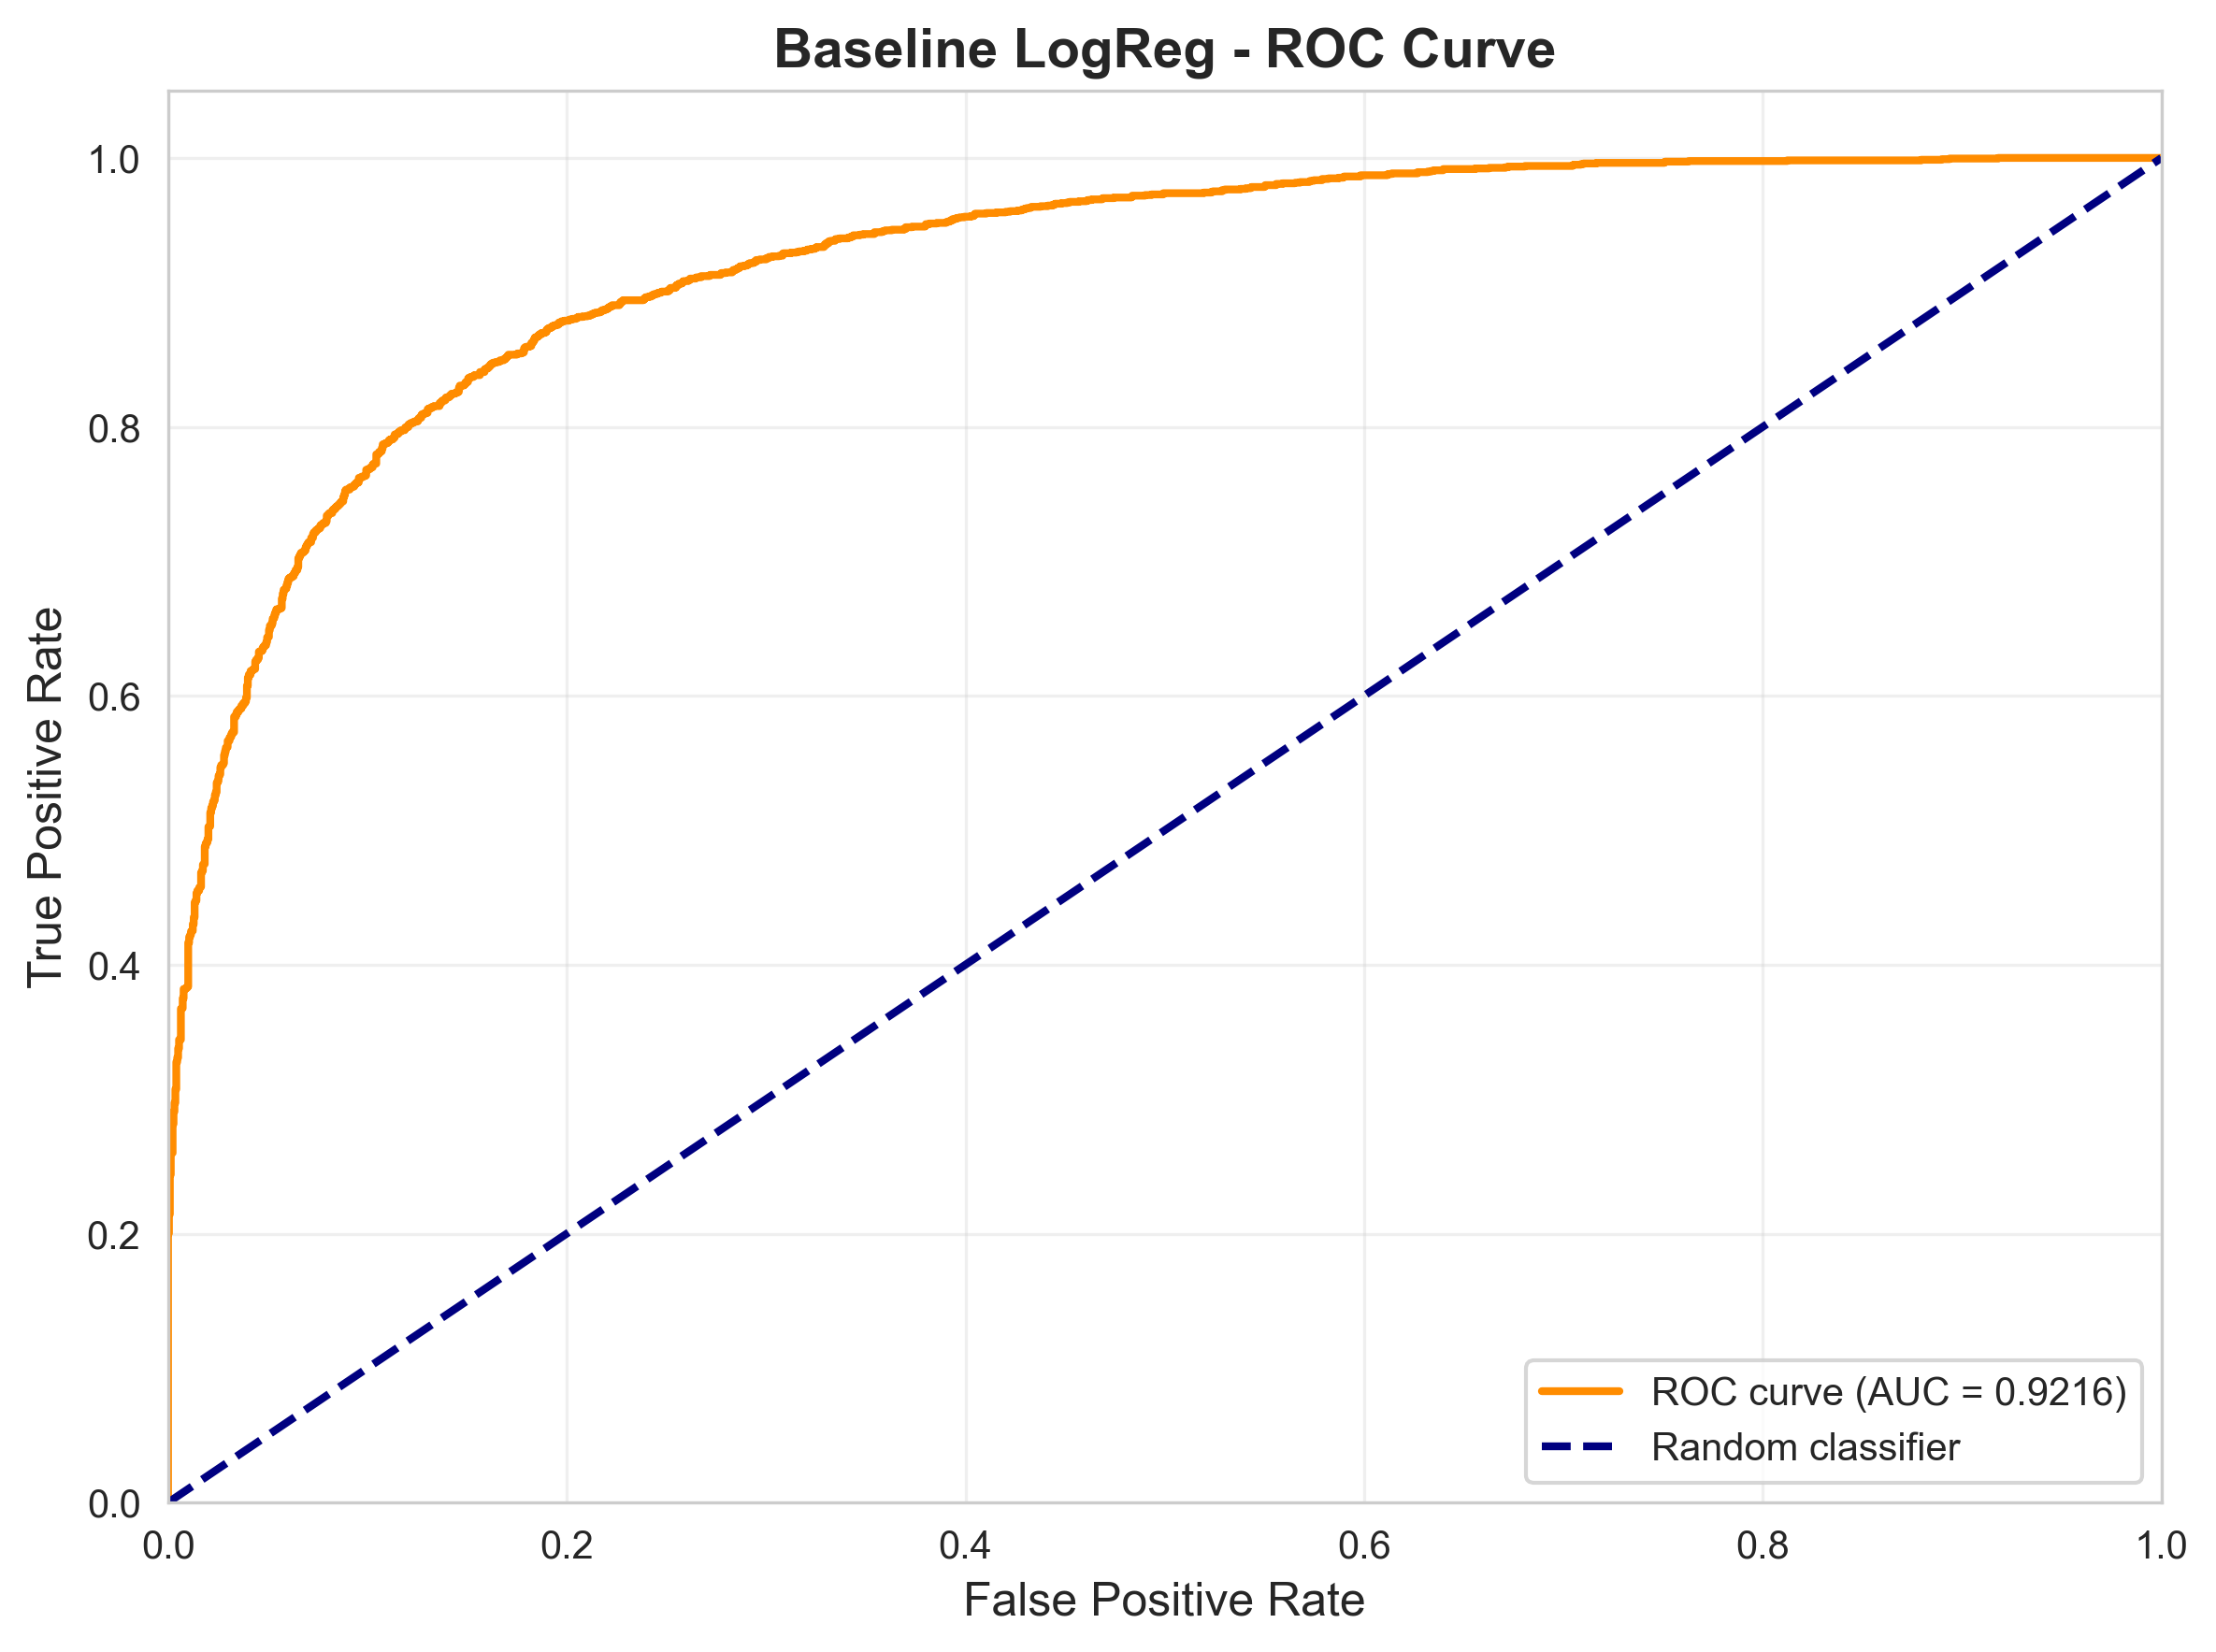

In [10]:
# Створення та збереження ROC curve
save_roc_curve(
    y_test, y_proba,
    path='plots/01_baseline_roc_curve.png',
    title='Baseline LogReg - ROC Curve'
)

# Відображення inline
display(Image('plots/01_baseline_roc_curve.png'))

### 8.3 Топ-20 слів FAKE vs TRUE

✓ Top features збережено: plots/01_baseline_top_features.png


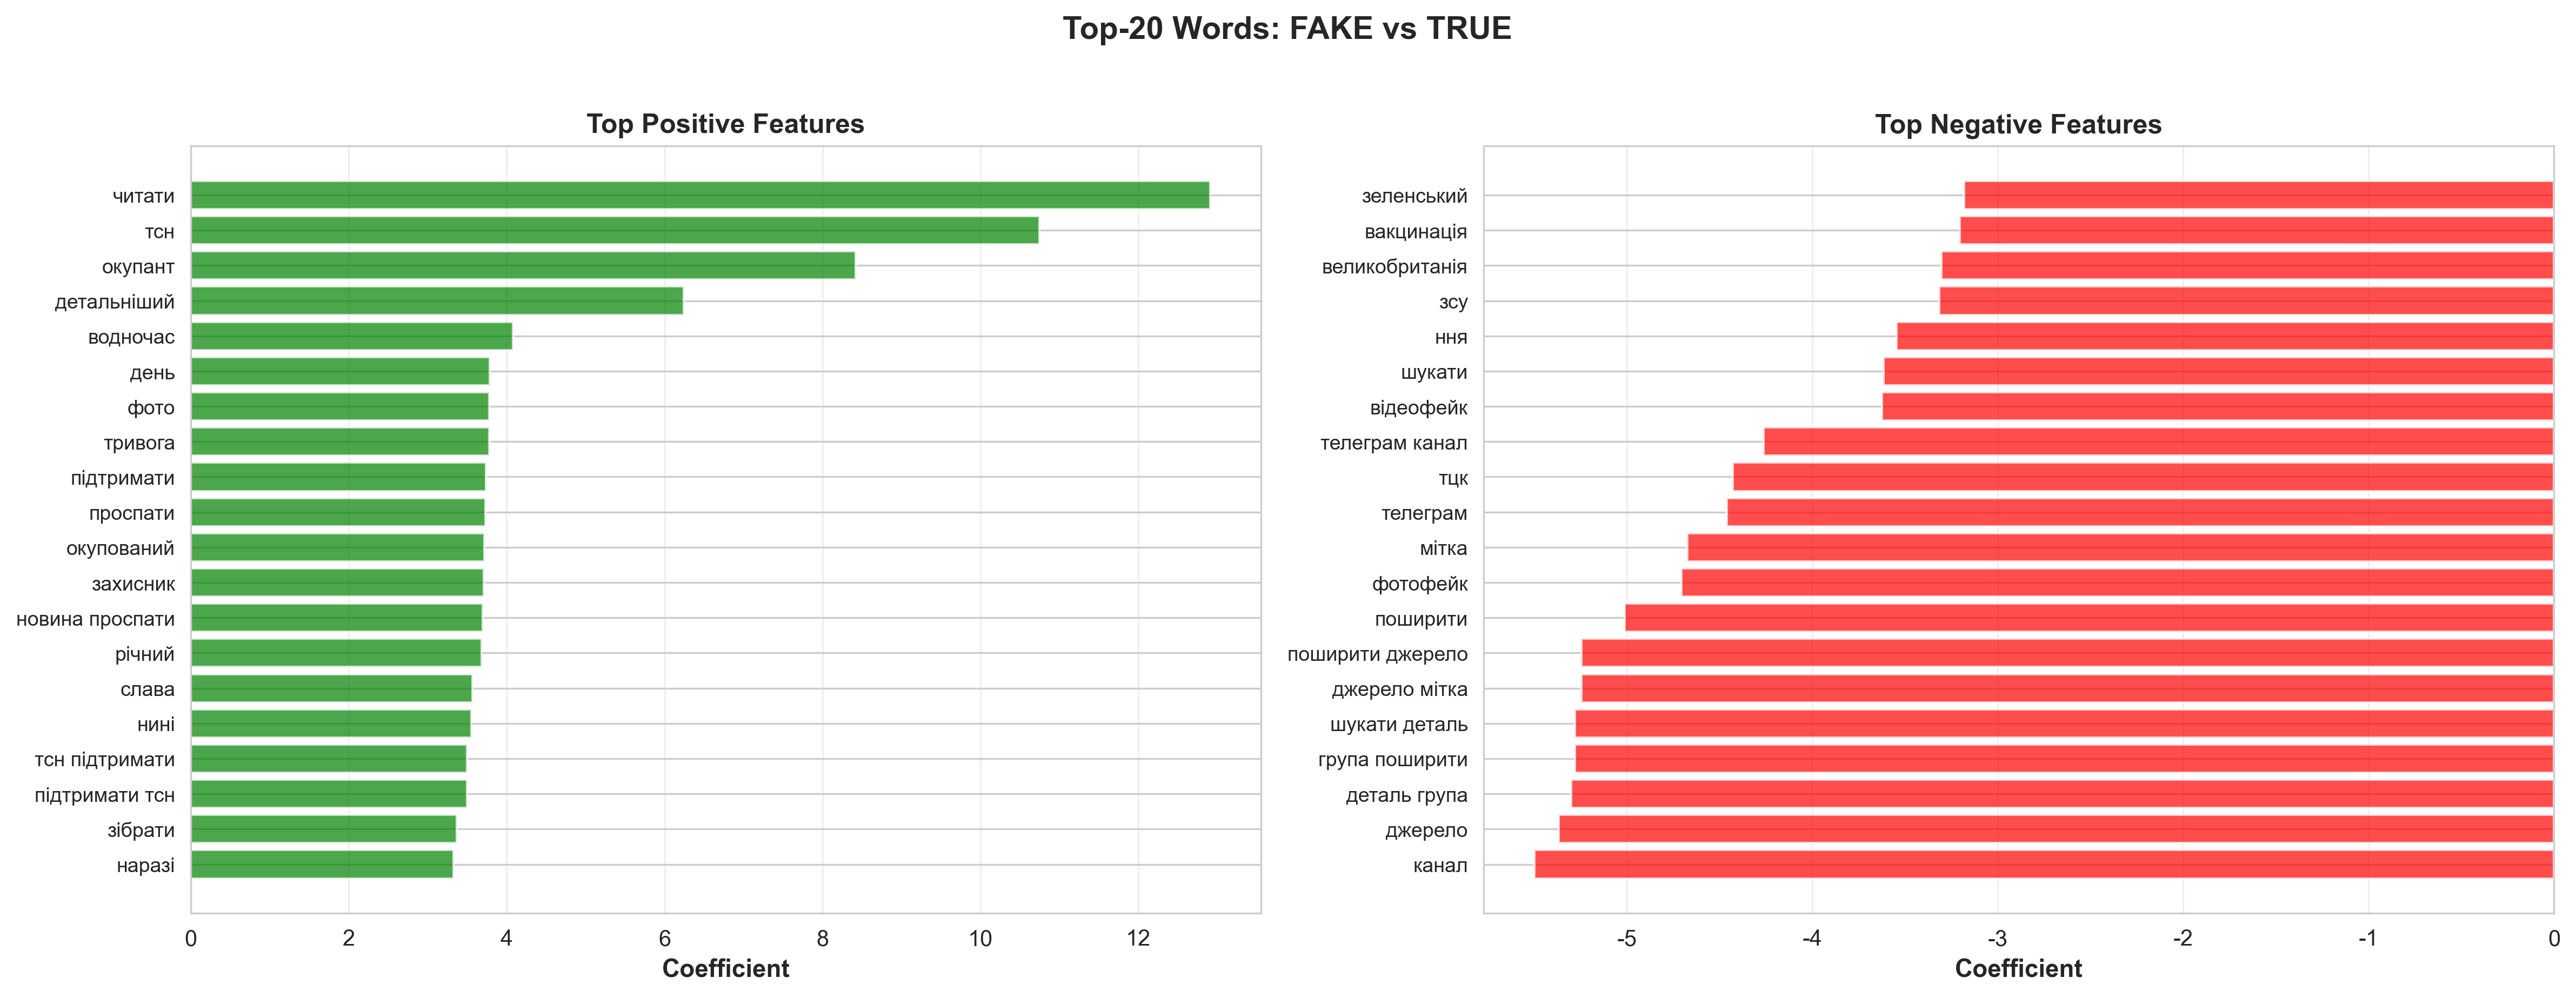

In [11]:
# Отримання feature names та coefficients
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = model.coef_[0]

# Створення та збереження топ features
save_top_features(
    feature_names, coefficients, n_top=20,
    path='plots/01_baseline_top_features.png',
    title='Top-20 Words: FAKE vs TRUE'
)

# Відображення inline
display(Image('plots/01_baseline_top_features.png'))

## 9. Збереження моделі та результатів

In [14]:
# Створення директорій
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Збереження моделі та vectorizer
joblib.dump(model, r'C:\Users\igrew\OneDrive\Desktop\Course Work\experiments\models\01\baseline_logreg_model.pkl')
joblib.dump(vectorizer, r'C:\Users\igrew\OneDrive\Desktop\Course Work\experiments\models\01\baseline_logreg_vectorizer.pkl')
print("✓ Модель збережено: ../models/baseline_logreg_model.pkl")
print("✓ Vectorizer збережено: ../models/baseline_logreg_vectorizer.pkl")

# Збереження метрик
save_metrics(
    metrics,
    path='results/01_baseline_fake_metrics.json',
    model_name='Baseline_LogReg'
)

print("\n" + "="*60)
print("  01_BASELINE_FAKE - ЗАВЕРШЕНО")
print("="*60)
print(f"  Accuracy:  {metrics['accuracy']:.4f}")
print(f"  Precision: {metrics['precision']:.4f}")
print(f"  Recall:    {metrics['recall']:.4f}")
print(f"  F1-Score:  {metrics['f1']:.4f}")
print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
print("="*60)

✓ Модель збережено: ../models/baseline_logreg_model.pkl
✓ Vectorizer збережено: ../models/baseline_logreg_vectorizer.pkl
✓ Метрики збережено: results/01_baseline_fake_metrics.json

  01_BASELINE_FAKE - ЗАВЕРШЕНО
  Accuracy:  0.8408
  Precision: 0.8541
  Recall:    0.8219
  F1-Score:  0.8377
  ROC-AUC:   0.9216
